In [44]:
# Load all metrics npz files from Results/{timestamp}.
# They are named metrics_{experiment}_{sampler}_{proposal}.npz, and the
# experiment name is {dataset}_ss{NN}_{sampler} for the subsampling runs
# (metrics_covtype_ss10_smc_smc_DA.npz) but {dataset}_{sampler} for the rest
# (metrics_covtype_mcmc_mcmc_MH.npz) -- so the ss field is not always there.

import os
import re

import numpy as np


def load_metrics_files(timestamp, results_root="Results"):
    """(smc, mcmc) lists of dicts, one per metrics_*.npz in the run directory."""
    results_path = os.path.join(results_root, timestamp)

    smc_samplers = []
    mcmc_samplers = []

    for filename in sorted(os.listdir(results_path)):
        if not (filename.startswith("metrics_") and filename.endswith(".npz")):
            continue

        # Split from the right: the experiment name itself contains "_", so
        # only the last two fields are in a fixed position.
        stem = filename[len("metrics_"):-len(".npz")]
        name, sampler, proposal = stem.rsplit("_", 2)
        dataset = name.split("_")[0]
        ss = re.search(r"_ss(\d+)", name)   # absent on the runs without subsampling
        ss_prop = int(ss.group(1)) / 100.0 if ss else None

        file_path = os.path.join(results_path, filename)
        with np.load(file_path) as npz:
            # Read the arrays out now: np.load is lazy and holds the file open.
            data = {key: npz[key] for key in npz.files}

        sampler_dict = {
            "name": name,
            "dataset": dataset,
            "ss_prop": ss_prop,
            "sampler": sampler,
            "proposal_mechanism": proposal,
            "path": file_path,
            "data": data,
        }

        if sampler == "smc":
            smc_samplers.append(sampler_dict)
        else:
            mcmc_samplers.append(sampler_dict)

    return smc_samplers, mcmc_samplers

In [ ]:
timestamp="260909_190928"
smc_results, mcmc_results = load_metrics_files(timestamp)

In [46]:
# Per-iteration runtime lives in the .h5 each metrics file was evaluated from:
# every Run_N group holds iter_time and cumulative_time, one entry per
# iteration (MCMC) or step (SMC). The clock times the sampler alone -- the
# time spent recording states is excluded.

import h5py


def load_runtime(experiment):
    """Cumulative sampling time in seconds, as an (n_runs, n_points) array
    lined up with the experiment's metric arrays."""
    metrics_dir, metrics_file = os.path.split(experiment['path'])
    h5_path = os.path.join(metrics_dir, metrics_file[len("metrics_"):-len(".npz")] + ".h5")
    iterations = experiment['data']['iterations']
    n_runs = int(experiment['data']['n_runs'])
    with h5py.File(h5_path, "r") as f:
        runs = sorted((k for k in f if k.startswith("Run_")), key=lambda k: int(k[len("Run_"):]))
        return np.stack([f[run]["cumulative_time"][()][iterations] for run in runs[:n_runs]])


for experiment in smc_results + mcmc_results:
    experiment['time'] = load_runtime(experiment)

In [47]:
for i in range(len(smc_results)):
    print(smc_results[i]['ss_prop'])

None
0.1
0.1
0.25
0.25
0.5
0.5


In [58]:
list(smc_results[0]['data'].keys())

['iterations',
 'stride',
 'n_runs',
 'test_accuracy',
 'test_balanced_accuracy',
 'test_brier',
 'test_confusion',
 'test_log_loss',
 'test_macro_f1',
 'test_macro_precision',
 'test_macro_recall',
 'train_accuracy',
 'train_balanced_accuracy',
 'train_brier',
 'train_confusion',
 'train_log_loss',
 'train_macro_f1',
 'train_macro_precision',
 'train_macro_recall']

In [ ]:
tasks_ss_prop = [0.1, 0.25, 0.5]
tasks_proposals = ["DA","MH","HINTS"]
line_colours = {
    'MH':       ['#009E73'],
    'DA':    ['#8B0A2E', '#D55E00', '#E69F00', '#F0E442'],
    'HINTS': ['#56B4E9', '#0072B2', '#2B2B7F', '#7B3294']}
shade_colours = {
    'MH':       ['#99D8C7'],
    'DA':    ['#E3B5C1', '#F2BF99', '#F5D999', '#FAF4B3'],
    'HINTS': ['#BBE1F6', '#99C7E0', '#B9B9DC', '#C4A3CF']}
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams.update({'text.usetex': False})

In [50]:
smc_results[0]['data']['train_accuracy']

array([[0.50047439, 0.51943056, 0.5222855 , ..., 0.7047583 , 0.7047583 ,
        0.7047583 ],
       [0.50047439, 0.51943056, 0.5222855 , ..., 0.71027024, 0.71027024,
        0.71027024],
       [0.50047439, 0.51943056, 0.5222855 , ..., 0.69418191, 0.69418191,
        0.69418191],
       ...,
       [0.5126794 , 0.51943056, 0.5222855 , ..., 0.7074067 , 0.7074067 ,
        0.7074067 ],
       [0.5126794 , 0.51943056, 0.5222855 , ..., 0.70623633, 0.70623633,
        0.70623633],
       [0.5126794 , 0.51943056, 0.5222855 , ..., 0.69507905, 0.69507905,
        0.69507905]], shape=(20, 1000))

In [51]:
line_colours = {
    'MH':    ['#009E73'],
    'DA':    ['#8B0A2E', '#D55E00', '#E69F00', '#F0E442'],
    'HINTS': ['#56B4E9', '#0072B2', '#2B2B7F', '#7B3294']}
shade_colours = {
    'MH':    ['#99D8C7'],
    'DA':    ['#E3B5C1', '#F2BF99', '#F5D999', '#FAF4B3'],
    'HINTS': ['#BBE1F6', '#99C7E0', '#B9B9DC', '#C4A3CF']}
X_LABELS = {"iteration": "Iteration", "time": "Sampling time (s)"}


def colour_index(experiment, results):
    """Rank of this experiment's ss_prop among its proposal's ss_props, so each
    subsample size keeps the same colour in every plot."""
    proposal = experiment['proposal_mechanism']
    ss_values = sorted({e['ss_prop'] for e in results if e['proposal_mechanism'] == proposal},
                       key=lambda s: -1 if s is None else s)
    return ss_values.index(experiment['ss_prop']) % len(line_colours[proposal])


def curve(experiment, key, x="iteration", n_grid=500):
    """(x values, mean, std) of a metric across runs, against iteration or,
    with x="time", against cumulative sampling time in seconds."""
    values = experiment['data'][key]                      # (n_runs, n_points)
    if x == "iteration":
        return experiment['data']['iterations'], values.mean(axis=0), values.std(axis=0)
    # Runs finish at different wallclock times, so they are averaged on a shared
    # time grid that stops when the fastest run finished; at each grid time a
    # run holds the value of the last iteration it had completed.
    times = experiment['time']
    grid = np.linspace(0.0, times[:, -1].min(), n_grid)
    at_grid = np.stack([v[np.clip(np.searchsorted(t, grid, side="right") - 1, 0, None)]
                        for t, v in zip(times, values)])
    return grid, at_grid.mean(axis=0), at_grid.std(axis=0)


def plot_metric(results, key, title, ylabel, x="iteration"):
    plt.figure(figsize=(8, 6))
    for experiment in results:
        proposal = experiment['proposal_mechanism']
        k = colour_index(experiment, results)
        xs, mean, std = curve(experiment, key, x)
        label = proposal if experiment['ss_prop'] is None else f"{proposal} ss={experiment['ss_prop']}"
        plt.fill_between(xs, mean - std, mean + std, color=shade_colours[proposal][k], alpha=0.5, zorder=1)
        plt.plot(xs, mean, label=label, color=line_colours[proposal][k], zorder=2)
    plt.title(title)
    plt.xlabel(X_LABELS[x])
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# same as above but separate HINTS and DA into 2 subplots with MH on both
def plot_metric_split(results, key, title, ylabel, x="iteration"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for experiment in results:
        proposal = experiment['proposal_mechanism']
        k = colour_index(experiment, results)
        xs, mean, std = curve(experiment, key, x)
        label = proposal if experiment['ss_prop'] is None else f"{proposal} ss={experiment['ss_prop']}"
        if proposal == "DA":
            ax = axes[0]
        elif proposal == "HINTS":
            ax = axes[1]
        elif proposal == "MH":
            for ax in axes:
                ax.fill_between(xs, mean - std, mean + std, color=shade_colours[proposal][k], alpha=0.5, zorder=1)
                ax.plot(xs, mean, label=label, color=line_colours[proposal][k], zorder=2)
        if proposal in ["DA", "HINTS"]:
            ax.fill_between(xs, mean - std, mean + std, color=shade_colours[proposal][k], alpha=0.5, zorder=1)
            ax.plot(xs, mean, label=label, color=line_colours[proposal][k], zorder=2)
        ax.set_title(f"{title} ({proposal})")
        ax.set_xlabel(X_LABELS[x])
        ax.set_ylabel(ylabel)
        ax.legend()
    plt.show()


# plot_metric(smc_results, 'train_accuracy', "Training Accuracy", "Accuracy")

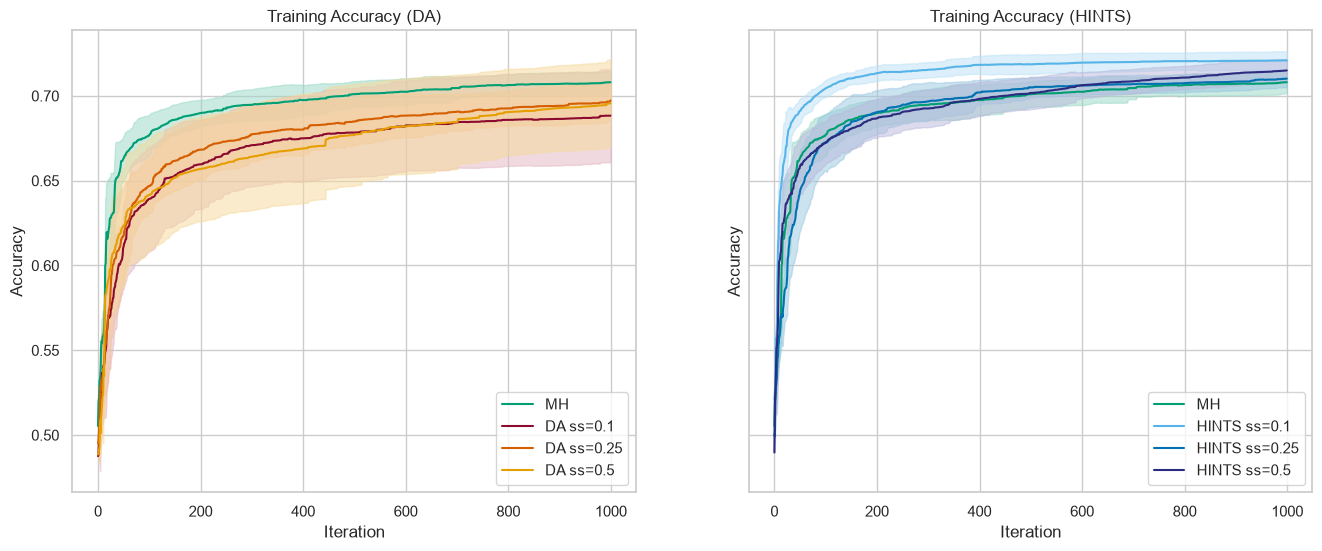

In [52]:
plot_metric_split(smc_results, 'train_accuracy', "Training Accuracy", "Accuracy")

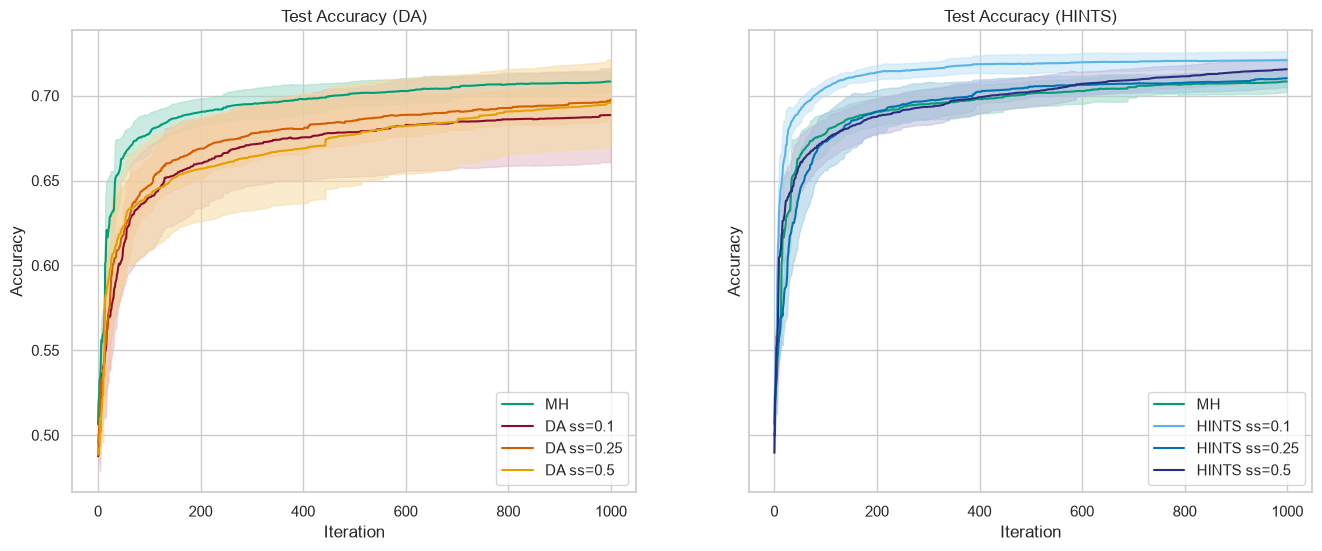

In [53]:
plot_metric_split(smc_results, 'test_accuracy', "Test Accuracy", "Accuracy")


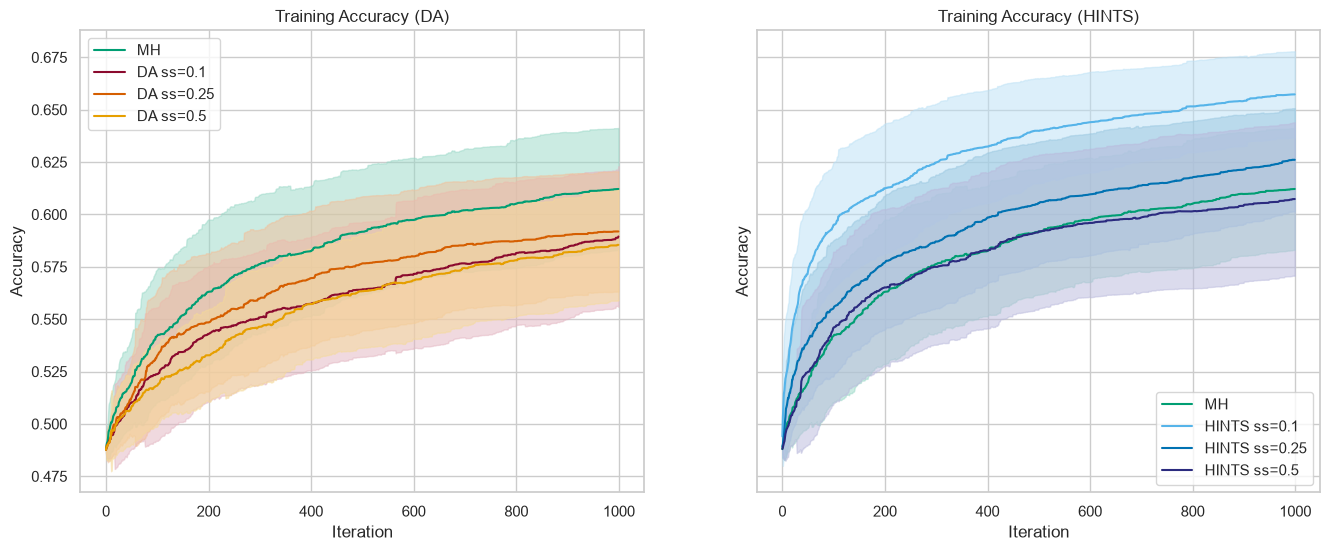

In [54]:
plot_metric_split(mcmc_results, 'train_accuracy', "Training Accuracy", "Accuracy")


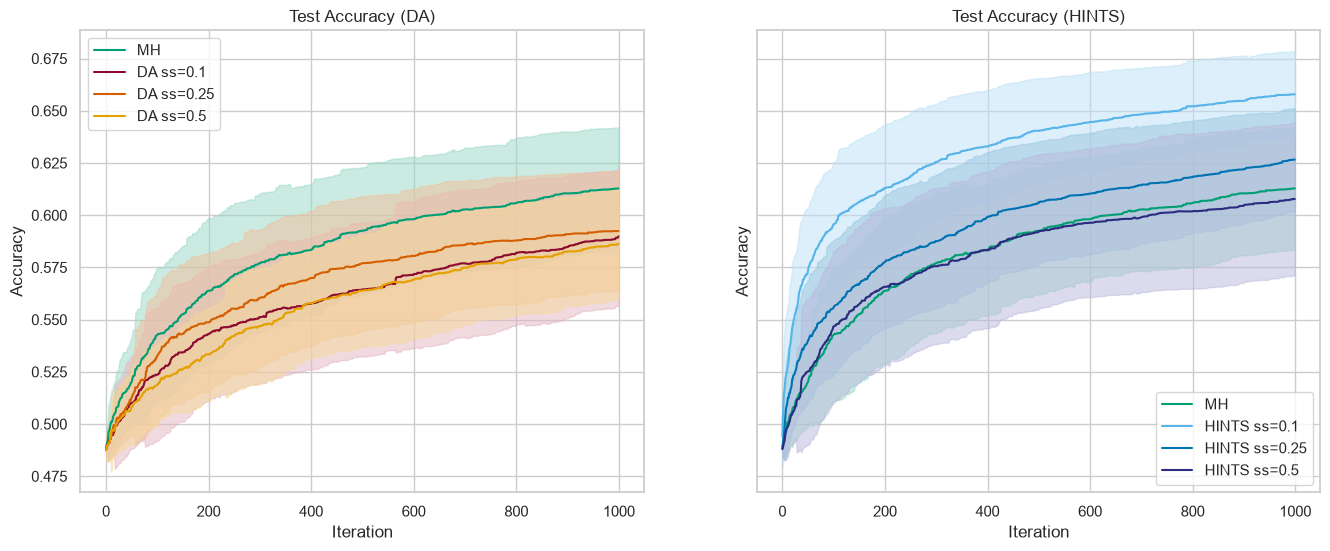

In [55]:
plot_metric_split(mcmc_results, 'test_accuracy', "Test Accuracy", "Accuracy")


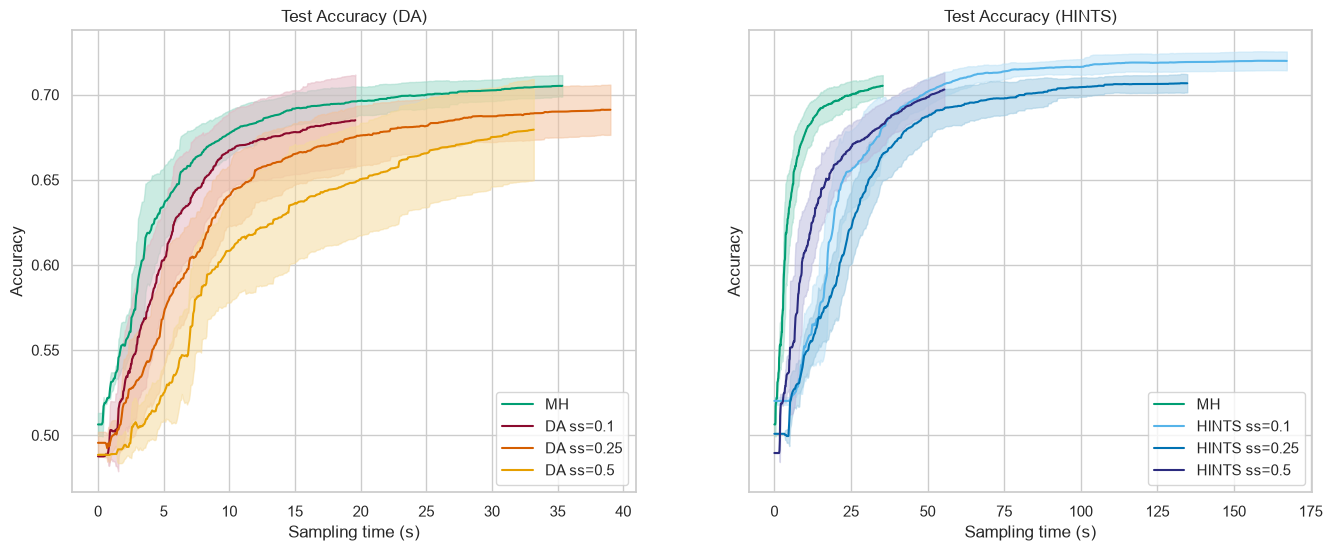

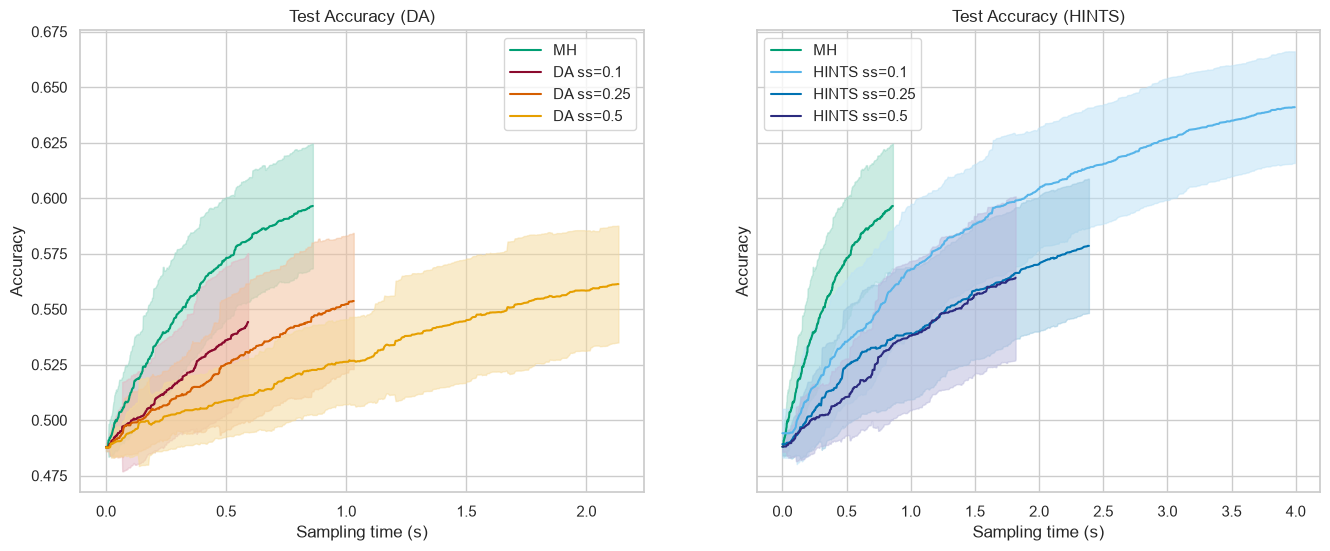

In [56]:
plot_metric_split(smc_results, 'test_accuracy', "Test Accuracy", "Accuracy", x="time")
plot_metric_split(mcmc_results, 'test_accuracy', "Test Accuracy", "Accuracy", x="time")

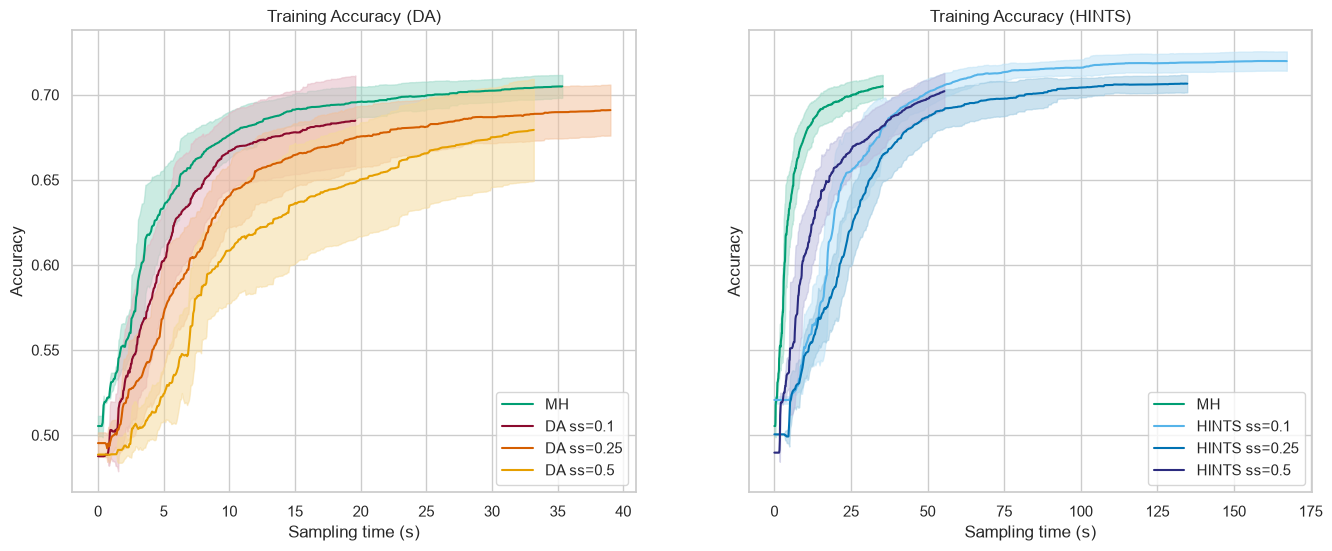

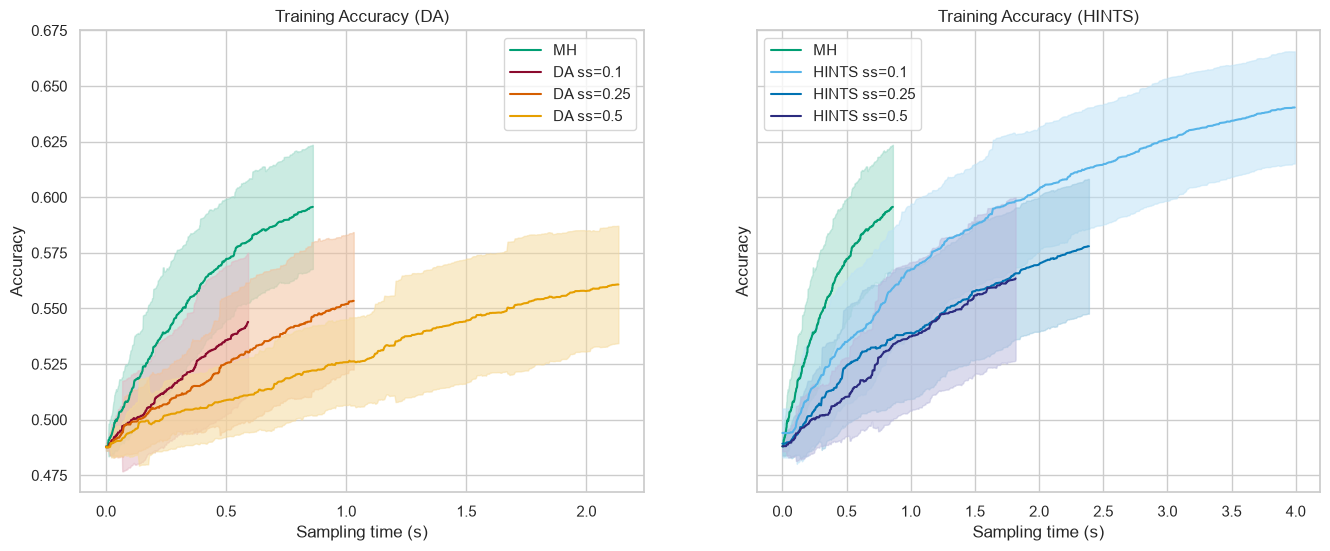

In [57]:
plot_metric_split(smc_results, 'train_accuracy', "Training Accuracy", "Accuracy", x="time")
plot_metric_split(mcmc_results, 'train_accuracy', "Training Accuracy", "Accuracy", x="time")